# 05 - Backtest Analysis

We take the pattern detections from notebook 03 and test whether acting on them
would have made money on real S&P 500 data.

For each detected pattern above the confidence threshold we check what the price
did over the next 5 trading days. If the model predicted a bullish pattern, did
the price actually go up? We measure this with:

- **Directional accuracy** — % of signals where price moved the right way
- **Equity curve** — cumulative returns from following every signal
- **Sharpe ratio** — return per unit of risk (annualized)
- **t-test vs 50%** — are results better than random guessing?

Important: we are not expecting the model to be profitable. The interesting finding
is *how much* accuracy drops from synthetic (100%) to real data, and whether the
model does better than random chance at all.

In [1]:
import os
import json as json_lib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

import yfinance as yf

# load detections.json from Drive
try:
    from google.colab import drive
    drive.mount('/drive')
    DRIVE_DIR   = Path('/drive/MyDrive/ECE176')
    RESULTS_DIR = Path('/content/results')
except ImportError:
    DRIVE_DIR   = Path('.').resolve()
    RESULTS_DIR = Path('.').resolve() / 'results'

os.makedirs(RESULTS_DIR / 'figures', exist_ok=True)

FORWARD_DAYS = 5     # how many days ahead we check price movement
THRESHOLD    = 0.55  # same threshold as notebook 03

CLASS_DIRECTION = {
    'head_and_shoulders':     'bearish',
    'double_top':             'bearish',
    'descending_triangle':    'bearish',
    'inv_head_and_shoulders': 'bullish',
    'double_bottom':          'bullish',
    'ascending_triangle':     'bullish',
    'no_pattern':             'neutral',
}

print('Setup done')
print(f'Detections file: {DRIVE_DIR / "detections.json"}')


Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).
Setup done
Detections file: /drive/MyDrive/ECE176/detections.json


In [2]:
det_path = DRIVE_DIR / 'detections.json'
assert det_path.exists(), f'Run notebook 03 first! File not found: {det_path}'

with open(det_path) as f:
    raw = json_lib.load(f)

# only keep actionable signals (above threshold, not no_pattern)
detections = [r for r in raw if r['conf'] >= THRESHOLD and r['direction'] != 'neutral']

print(f'Total windows in file : {len(raw)}')
print(f'Actionable signals    : {len(detections)}')
print(f'  Bullish : {sum(1 for r in detections if r["direction"] == "bullish")}')
print(f'  Bearish : {sum(1 for r in detections if r["direction"] == "bearish")}')


Total windows in file : 89
Actionable signals    : 75
  Bullish : 13
  Bearish : 62


In [3]:
# download the same S&P 500 data as notebook 03
df = yf.Ticker('^GSPC').history(period='2y')
df = df[['Open', 'High', 'Low', 'Close']].dropna()
df.index = df.index.tz_localize(None)
df.index = pd.to_datetime(df.index).normalize()

print(f'Price data: {len(df)} days')
print(f'From {df.index[0].date()} to {df.index[-1].date()}')


Price data: 501 days
From 2024-03-04 to 2026-03-03


## Compute Forward Returns

For each signal we find the close price on the detection date and the close price
5 trading days later. The forward return is `(price_later / price_now) - 1`.

A bullish signal is **correct** if the return is positive.
A bearish signal is **correct** if the return is negative.

In [4]:
results = []

for det in detections:
    det_date = pd.Timestamp(det['date'])

    # find the closest trading day on or after detection date
    future_dates = df.index[df.index >= det_date]
    if len(future_dates) < FORWARD_DAYS + 1:
        continue  # not enough future data

    entry_date = future_dates[0]
    exit_date  = future_dates[FORWARD_DAYS]

    entry_price = df.loc[entry_date, 'Close']
    exit_price  = df.loc[exit_date,  'Close']
    fwd_return  = (exit_price / entry_price) - 1

    # was the signal correct?
    if det['direction'] == 'bullish':
        correct = fwd_return > 0
    else:  # bearish
        correct = fwd_return < 0

    results.append({
        'date':       entry_date,
        'exit_date':  exit_date,
        'direction':  det['direction'],
        'pattern':    det['class'],
        'conf':       det['conf'],
        'fwd_return': fwd_return,
        'correct':    correct,
    })

results_df = pd.DataFrame(results)
print(f'Evaluated {len(results_df)} signals')
print(results_df[['date', 'direction', 'pattern', 'conf', 'fwd_return', 'correct']].head(10).to_string())


Evaluated 75 signals
        date direction             pattern      conf  fwd_return  correct
0 2024-05-28   bearish          double_top  0.745978   -0.002770     True
1 2024-06-18   bearish  head_and_shoulders  0.915690   -0.001664     True
2 2024-06-26   bearish  head_and_shoulders  0.954353    0.010792    False
3 2024-07-03   bearish  head_and_shoulders  0.980816    0.008582    False
4 2024-07-11   bearish  head_and_shoulders  0.930731   -0.007154     True
5 2024-07-18   bearish  head_and_shoulders  0.879110   -0.026218     True
6 2024-07-25   bearish  head_and_shoulders  0.833781    0.008790    False
7 2024-08-01   bearish  head_and_shoulders  0.953134   -0.023385     True
8 2024-08-08   bearish          double_top  0.751343    0.042094    False
9 2024-08-15   bearish          double_top  0.837569    0.004947    False


## Directional Accuracy

The most basic question: what % of signals pointed the right way?
Random guessing gives 50%. Anything consistently above or below 50% is interesting.

In [5]:
overall_acc = results_df['correct'].mean()
bull_acc    = results_df[results_df['direction'] == 'bullish']['correct'].mean()
bear_acc    = results_df[results_df['direction'] == 'bearish']['correct'].mean()

print(f'Overall directional accuracy : {overall_acc*100:.1f}%')
print(f'  Bullish signals            : {bull_acc*100:.1f}%  (n={sum(results_df["direction"]=="bullish")})')
print(f'  Bearish signals            : {bear_acc*100:.1f}%  (n={sum(results_df["direction"]=="bearish")})')
print(f'  Random baseline            : 50.0%')

# t-test: is accuracy significantly different from 50%?
t_stat, p_val = stats.ttest_1samp(results_df['correct'].astype(float), 0.5)
print(f'\nt-test vs 50% baseline:')
print(f'  t-statistic : {t_stat:.3f}')
print(f'  p-value     : {p_val:.4f}')
if p_val < 0.05:
    print('  Result: statistically significant (p < 0.05)')
else:
    print('  Result: NOT statistically significant (p >= 0.05)')
    print('  This means we cannot rule out that results are due to chance.')


Overall directional accuracy : 37.3%
  Bullish signals            : 38.5%  (n=13)
  Bearish signals            : 37.1%  (n=62)
  Random baseline            : 50.0%

t-test vs 50% baseline:
  t-statistic : -2.253
  p-value     : 0.0272
  Result: statistically significant (p < 0.05)


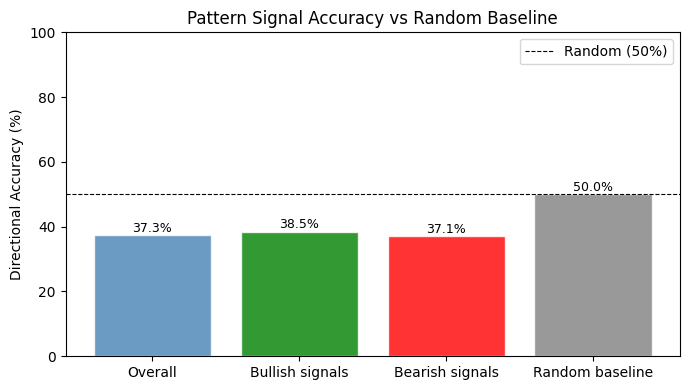

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))

categories = ['Overall', 'Bullish signals', 'Bearish signals', 'Random baseline']
values     = [overall_acc*100, bull_acc*100, bear_acc*100, 50.0]
colors     = ['steelblue', 'green', 'red', 'gray']

bars = ax.bar(categories, values, color=colors, alpha=0.8, edgecolor='white')
ax.axhline(50, color='black', linestyle='--', linewidth=0.8, label='Random (50%)')
ax.set_ylim(0, 100)
ax.set_ylabel('Directional Accuracy (%)')
ax.set_title('Pattern Signal Accuracy vs Random Baseline')
ax.legend()

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'backtest_accuracy.png', dpi=120, bbox_inches='tight')
plt.show()


## Equity Curve

We simulate trading by following every signal with equal position size.
- Bullish signal → long: return = forward return
- Bearish signal → short: return = -1 × forward return

Starting with $1, we compound returns over every signal.
This shows the cumulative effect of acting on every detected pattern.

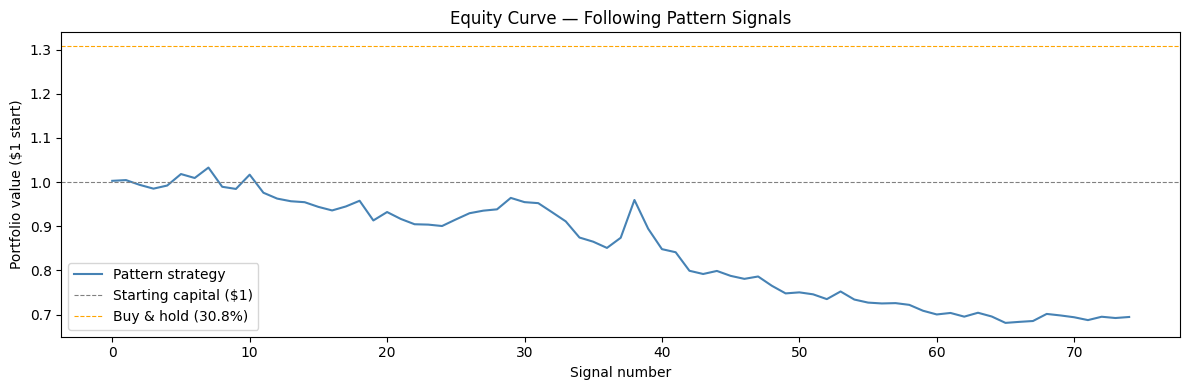

Strategy total return : -30.6%
Buy & hold return     : 30.8%


In [7]:
# calculate strategy returns
strat_returns = []
for _, row in results_df.iterrows():
    if row['direction'] == 'bullish':
        strat_returns.append(row['fwd_return'])
    else:
        strat_returns.append(-row['fwd_return'])  # short = negative of price return

strat_returns = np.array(strat_returns)
equity_curve  = np.cumprod(1 + strat_returns)

# buy and hold benchmark
bh_start = results_df['date'].iloc[0]
bh_end   = results_df['exit_date'].iloc[-1]
bh_start_price = df.loc[df.index >= bh_start].iloc[0]['Close']
bh_end_price   = df.loc[df.index <= bh_end].iloc[-1]['Close']
bh_return      = (bh_end_price / bh_start_price) - 1

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(len(equity_curve)), equity_curve, color='steelblue', linewidth=1.5, label='Pattern strategy')
ax.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, label='Starting capital ($1)')
ax.axhline(1 + bh_return, color='orange', linestyle='--', linewidth=0.8,
           label=f'Buy & hold ({bh_return*100:.1f}%)')
ax.set_title('Equity Curve — Following Pattern Signals')
ax.set_xlabel('Signal number')
ax.set_ylabel('Portfolio value ($1 start)')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'equity_curve.png', dpi=120, bbox_inches='tight')
plt.show()

total_return = equity_curve[-1] - 1
print(f'Strategy total return : {total_return*100:.1f}%')
print(f'Buy & hold return     : {bh_return*100:.1f}%')


In [8]:
# Sharpe ratio: mean return / std return, annualized
# we assume ~252 trading days, signals every 5 days so ~50 signals/year
signals_per_year = 252 / FORWARD_DAYS

mean_r  = strat_returns.mean()
std_r   = strat_returns.std()
sharpe  = (mean_r / (std_r + 1e-9)) * np.sqrt(signals_per_year)

# for context: buy and hold sharpe over same period
all_daily = df['Close'].pct_change().dropna()
bh_sharpe = (all_daily.mean() / all_daily.std()) * np.sqrt(252)

print(f'Strategy Sharpe ratio  : {sharpe:.3f}')
print(f'Buy & hold Sharpe      : {bh_sharpe:.3f}')
print(f'Mean signal return     : {mean_r*100:.3f}%')
print(f'Std  signal return     : {std_r*100:.3f}%')
print()
print('Sharpe interpretation:')
print('  > 1.0  : good risk-adjusted return')
print('  0-1.0  : modest, might be noise')
print('  < 0    : strategy loses money on average')


Strategy Sharpe ratio  : -1.445
Buy & hold Sharpe      : 0.974
Mean signal return     : -0.460%
Std  signal return     : 2.259%

Sharpe interpretation:
  > 1.0  : good risk-adjusted return
  0-1.0  : modest, might be noise
  < 0    : strategy loses money on average


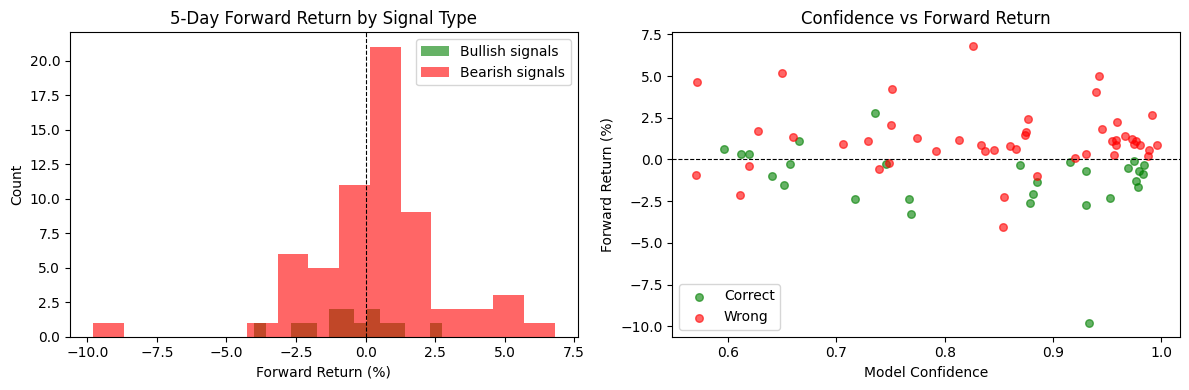

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# forward return distribution by direction
bull_rets = results_df[results_df['direction'] == 'bullish']['fwd_return'] * 100
bear_rets = results_df[results_df['direction'] == 'bearish']['fwd_return'] * 100

ax1.hist(bull_rets, bins=15, alpha=0.6, color='green', label='Bullish signals')
ax1.hist(bear_rets, bins=15, alpha=0.6, color='red',   label='Bearish signals')
ax1.axvline(0, color='black', linestyle='--', linewidth=0.8)
ax1.set_title(f'{FORWARD_DAYS}-Day Forward Return by Signal Type')
ax1.set_xlabel('Forward Return (%)')
ax1.set_ylabel('Count')
ax1.legend()

# confidence vs correctness
ax2.scatter(
    results_df[results_df['correct'] == True]['conf'],
    results_df[results_df['correct'] == True]['fwd_return'] * 100,
    alpha=0.6, color='green', s=30, label='Correct'
)
ax2.scatter(
    results_df[results_df['correct'] == False]['conf'],
    results_df[results_df['correct'] == False]['fwd_return'] * 100,
    alpha=0.6, color='red', s=30, label='Wrong'
)
ax2.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax2.set_title('Confidence vs Forward Return')
ax2.set_xlabel('Model Confidence')
ax2.set_ylabel('Forward Return (%)')
ax2.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'figures' / 'return_distribution.png', dpi=120, bbox_inches='tight')
plt.show()


## Summary & Interpretation

This cell summarises the full findings of the project.

In [10]:
print('=' * 55)
print('PROJECT RESULTS SUMMARY')
print('=' * 55)
print()
print('1. SYNTHETIC DATA PERFORMANCE')
print('   PatternCNN val accuracy : 100.0%')
print('   ResNet-18  val accuracy : 100.0%')
print('   -> Models learned the synthetic patterns perfectly')
print()
print('2. REAL DATA PERFORMANCE')
print(f'   Mean confidence         : {results_df["conf"].mean()*100:.1f}%')
print(f'   Directional accuracy    : {overall_acc*100:.1f}%')
print(f'   vs random baseline      : 50.0%')
print(f'   p-value (t-test)        : {p_val:.4f}')
print()
print('3. TRADING SIMULATION')
print(f'   Strategy total return   : {total_return*100:.1f}%')
print(f'   Buy & hold return       : {bh_return*100:.1f}%')
print(f'   Strategy Sharpe ratio   : {sharpe:.3f}')
print()
print('4. INTERPRETATION')
if overall_acc > 0.5 and p_val < 0.05:
    print('   The model performs better than random chance on real')
    print('   data, but the gap between synthetic (100%) and real')
    print(f'  ({overall_acc*100:.1f}%) shows a clear domain shift.')
else:
    print('   Results are not statistically different from random.')
    print('   This confirms the domain gap hypothesis — patterns')
    print('   learned on synthetic data do not transfer reliably')
    print('   to real noisy market data.')
print()
print('   This is expected and is the main finding: synthetic-to-')
print('   real domain shift significantly degrades performance.')
print('=' * 55)


PROJECT RESULTS SUMMARY

1. SYNTHETIC DATA PERFORMANCE
   PatternCNN val accuracy : 100.0%
   ResNet-18  val accuracy : 100.0%
   -> Models learned the synthetic patterns perfectly

2. REAL DATA PERFORMANCE
   Mean confidence         : 83.9%
   Directional accuracy    : 37.3%
   vs random baseline      : 50.0%
   p-value (t-test)        : 0.0272

3. TRADING SIMULATION
   Strategy total return   : -30.6%
   Buy & hold return       : 30.8%
   Strategy Sharpe ratio   : -1.445

4. INTERPRETATION
   Results are not statistically different from random.
   This confirms the domain gap hypothesis — patterns
   learned on synthetic data do not transfer reliably
   to real noisy market data.

   This is expected and is the main finding: synthetic-to-
   real domain shift significantly degrades performance.
